In [3]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.274 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge


In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10,20,30,40,50],
    'B': [5,15,25,35,45]})
print(data)
scaler = MinMaxScaler()
normalized_data=scaler.fit_transform(data)

normalized_df=pd.DataFrame(normalized_data, columns = data.columns)
print("normalized (Min-Max Scaling):")
print(normalized_df)

    A   B
0  10   5
1  20  15
2  30  25
3  40  35
4  50  45
normalized (Min-Max Scaling):
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)
standardized_df = pd.DataFrame(standardized_data, columns = data.columns)
print(standardized_df)

          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [7]:
df = pd.DataFrame({'color': ['Red', 'Blue', 'Green', 'Red', 'Blue']})
one_hot = pd.get_dummies(df, columns = ['color'])
print("\nOne-Hot Encoding:")
print(one_hot)


One-Hot Encoding:
   color_Blue  color_Green  color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [14]:
!pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, , LabelEncoder
import seaborn as sns
tips = sns.load_dataset("tips")
print("Original Data (first 5 rows):")
print(tips.head())
numeric_cols = tips.select_dtypes(include = ['float64', 'int64']).columns
scaler_minmax = MinMaxScaler()
tips_normalized = tips.copy()
tips_normalized[numeric_cols] = scaler_minmax.fit_transform(tips[numeric_cols])
print("\nNormalized Data(first 5 rows):")
print(tips_normalized.head())

#2. Standarlization(Z-score)
scaler_standard = StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols] = scaler_standard.fit_transform(tips[numeric_cols])
print("\nStandardized Data(first 5 rows):")
print(tips_standardized.head())

#3.Encoding Categorical Varaibles
#(a). One-Hot Encoding
tips_onehot = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'])
print("\nOne-Hot Encoded Data (first 5 rows):")
print(tips_onehot.head())

Original Data (first 5 rows):
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Normalized Data(first 5 rows):
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6

Standardized Data(first 5 rows):
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun  D

In [20]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tips = sns.load_dataset("tips")
numeric_cols = tips.select_dtypes(include = ['float64', 'int64'])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data = pca_result, columns = ['PC1','PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())


Explained variance ratio: [0.72627656 0.1730423 ]

PCA Result (first 5 rows):
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


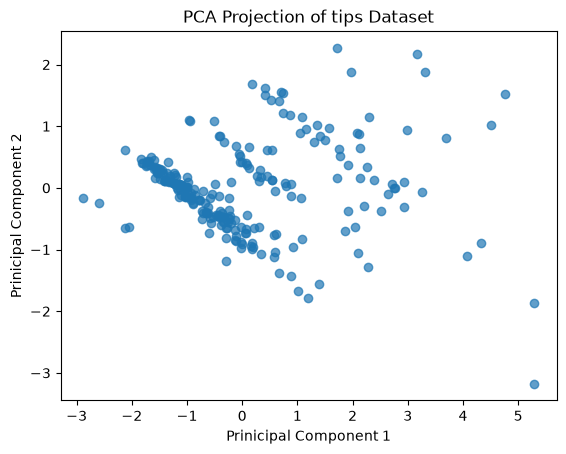

In [21]:
import matplotlib.pyplot as plt
plt.scatter(pca_df['PC1'], pca_df ['PC2'], alpha = 0.7)
plt.xlabel('Prinicipal Component 1')
plt.ylabel('Prinicipal Component 2')
plt.title('PCA Projection of tips Dataset')
plt.show()

In [22]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = pd.read_csv("Iris (1).csv")
numeric_cols = iris.select_dtypes(include = ['float64', 'int64'])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data = pca_result, columns = ['PC1','PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())

Explained variance ratio: [0.7470533  0.18435257]

PCA Result (first 5 rows):
        PC1       PC2
0 -2.816339  0.506051
1 -2.645527 -0.651799
2 -2.879481 -0.321036
3 -2.810934 -0.577363
4 -2.879884  0.670468


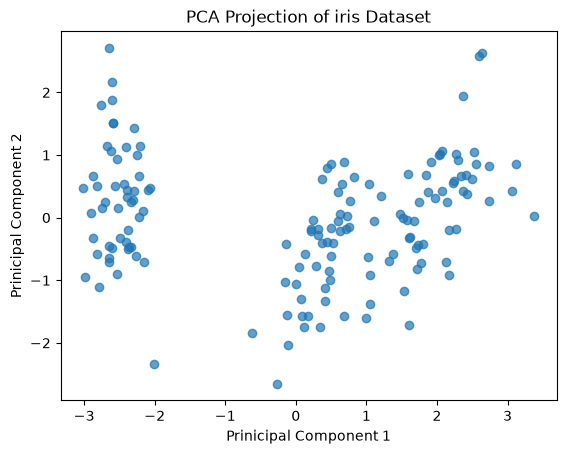

In [24]:
import matplotlib.pyplot as plt
plt.scatter(pca_df['PC1'], pca_df ['PC2'], alpha = 0.7)
plt.xlabel('Prinicipal Component 1')
plt.ylabel('Prinicipal Component 2')
plt.title('PCA Projection of iris Dataset')
plt.show()

In [4]:
%pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement numpy already satisfied.
Cannot install 'pandas' from PyPI because it is a binary built package that is not compatible with WASM environments. To resolve this issue, you can: 1) Try to install it from emscripten-forge instead: "!mamba install pandas" 2) If that doesn't work, it's probably that the package was not made WASM-compatible on emscripten-forge. You can either request or contribute a new recipe for that package in https://github.com/emscripten-forge/recipes 
Requirement matplotlib already satisfied.


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
data = sns.load_dataset("iris")
sns.pairplot(data,hue='species')
plt.show()

<class 'ModuleNotFoundError'>: No module named 'pandas'

In [7]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.214 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [8]:
!pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement seaborn already satisfied.


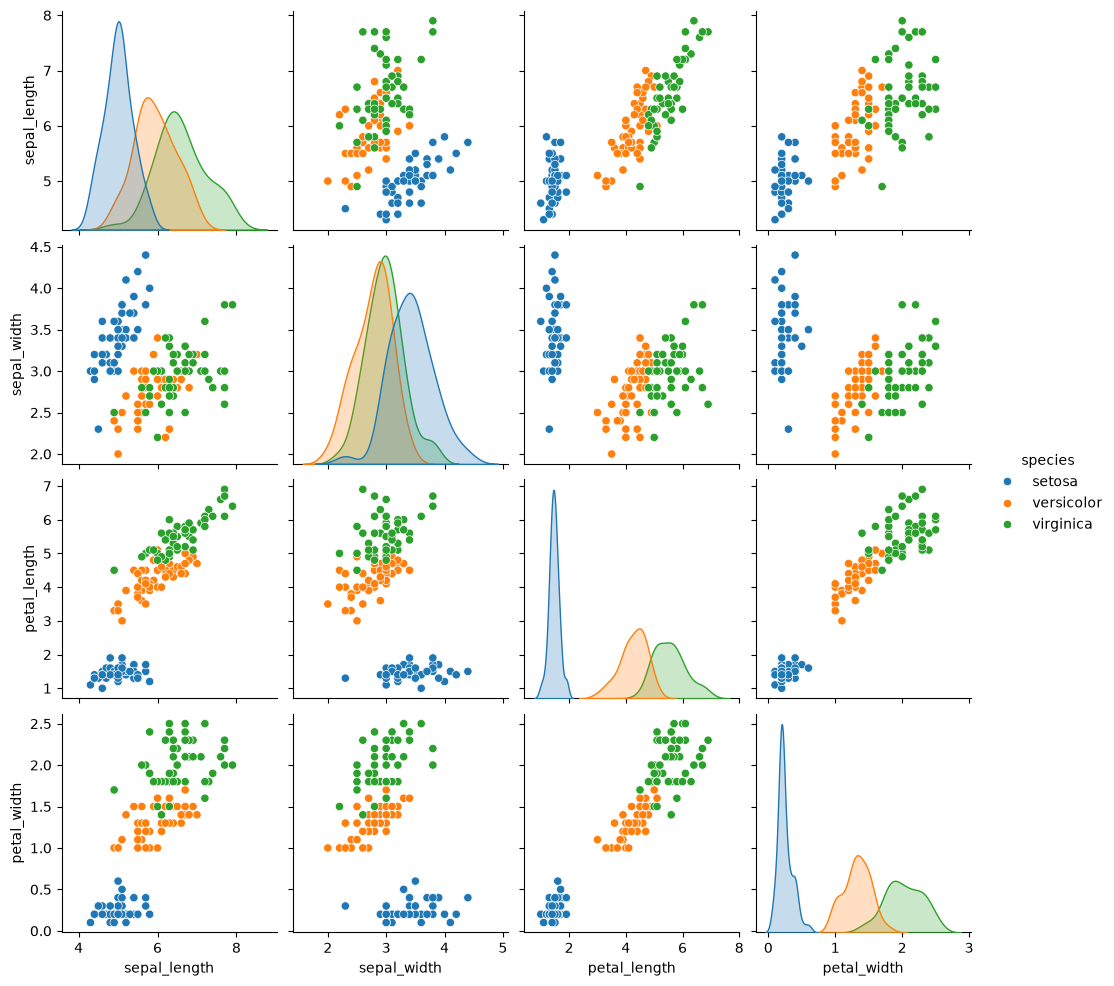

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
data = sns.load_dataset("iris")
sns.pairplot(data,hue='species')
plt.show()

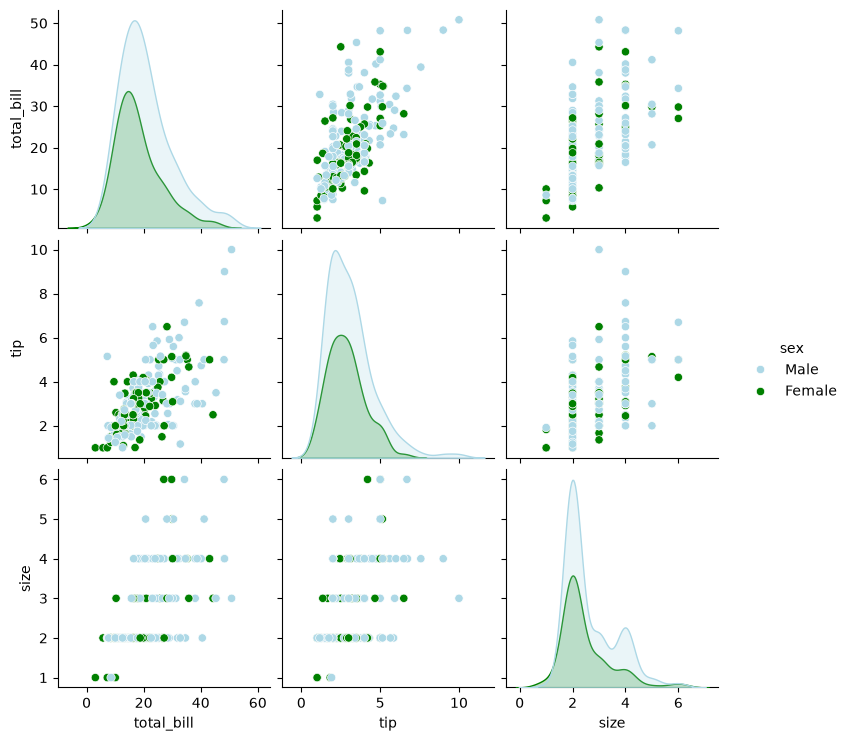

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
data=sns.load_dataset("tips")
c_p={'Male':'lightblue','Female':'green'}
sns.pairplot(data,hue='sex',palette=c_p)
plt.show()
                        

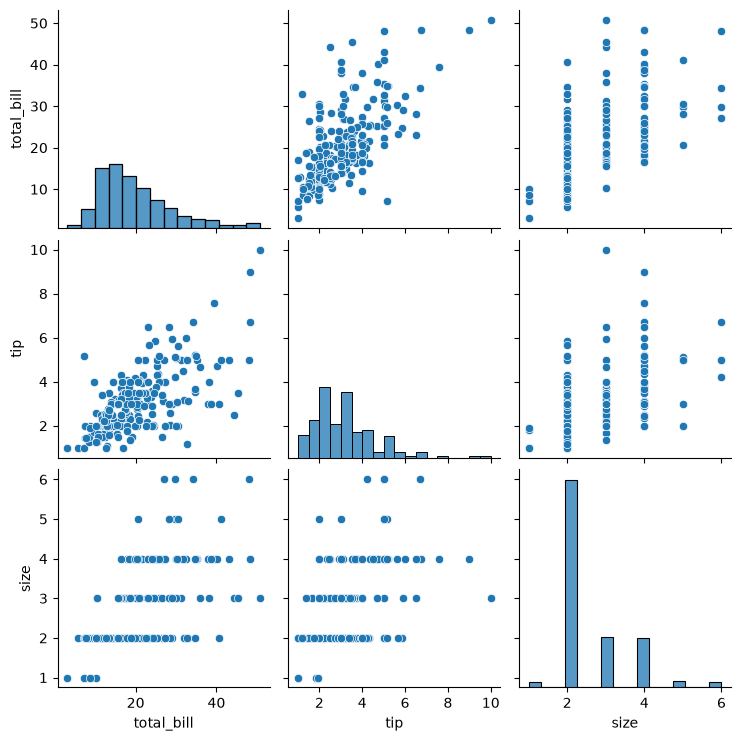

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
data=sns.load_dataset("tips")
sns.pairplot(data[['total_bill','tip','size']])
plt.show()

<Axes: ylabel='Density'>

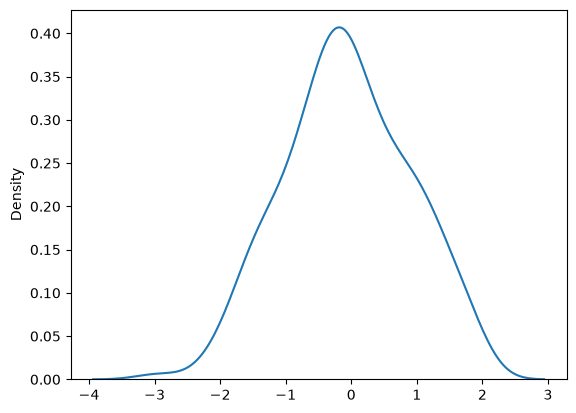

In [18]:
import seaborn as sns
import numpy as np
x = np.random.randn(200)
y = np.random.randn(200)
sns.kdeplot(x)

/tmp/xpython_42/1540431744.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,shade = True)


<Axes: ylabel='Density'>

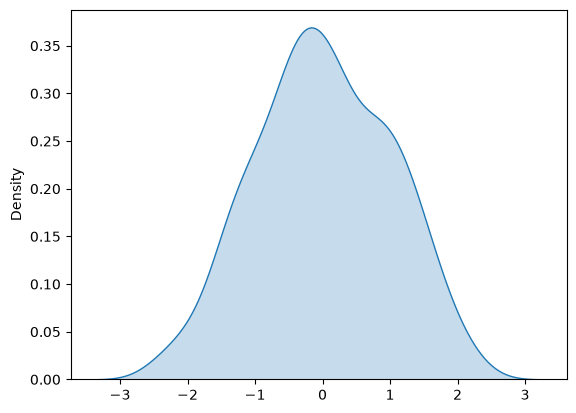

In [17]:
import seaborn as sns
import numpy as np
x = np.random.randn(200)
y = np.random.randn(200)
sns.kdeplot(x,shade = True)

/tmp/xpython_42/4137264956.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,shade = True)


<Axes: ylabel='Density'>

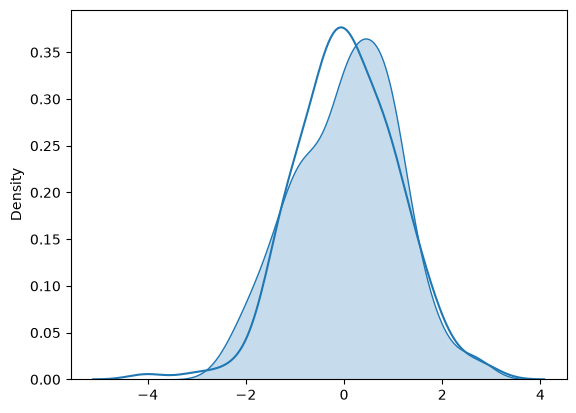

In [19]:
import seaborn as sns
import numpy as np
x = np.random.randn(200)
y = np.random.randn(200)
sns.kdeplot(x,shade = True)
sns.kdeplot(y)

/tmp/xpython_42/3798453816.py:5: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `x`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,vertical = False)


<Axes: ylabel='Density'>

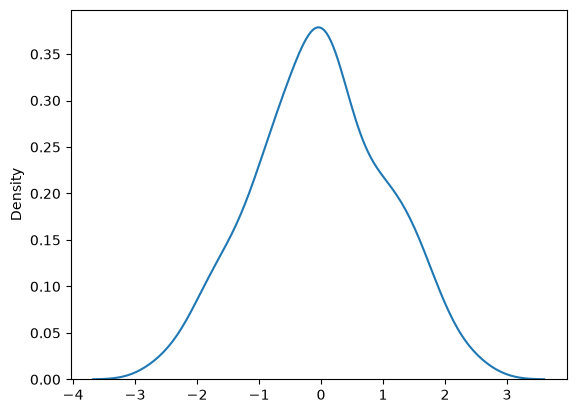

In [21]:
import seaborn as sns
import numpy as np
x = np.random.randn(200)
y = np.random.randn(200)
sns.kdeplot(x,vertical = False)

/tmp/xpython_42/953718981.py:5: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x,vertical = True)


<Axes: xlabel='Density'>

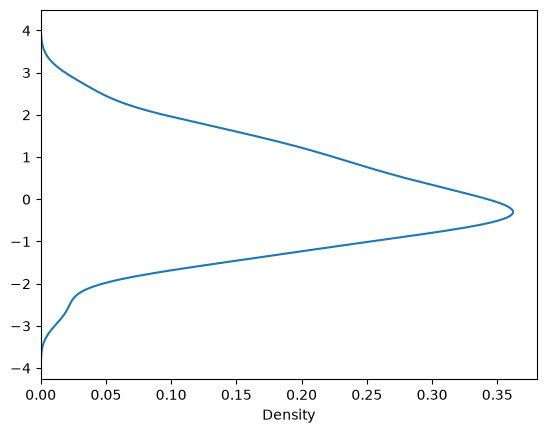

In [22]:
import seaborn as sns
import numpy as np
x = np.random.randn(200)
y = np.random.randn(200)
sns.kdeplot(x,vertical = True)

<Axes: >

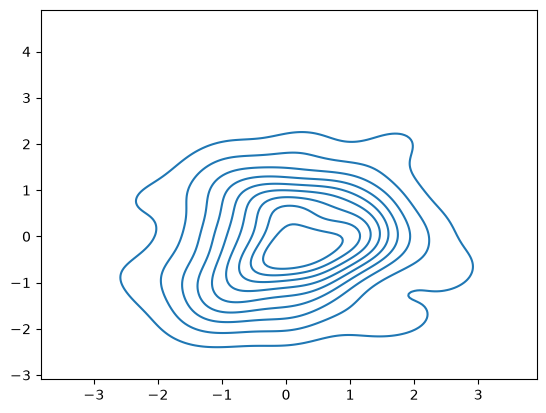

In [23]:
import seaborn as sns
import numpy as np
x = np.random.randn(200)
y = np.random.randn(200)
sns.kdeplot(x=x,y=y)

/tmp/xpython_42/278197391.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df['petal_width'],shade = True)


<Axes: xlabel='petal_length', ylabel='Density'>

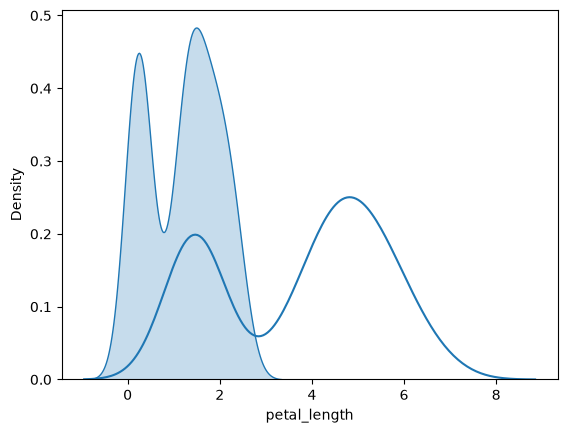

In [24]:
import seaborn as sns
df = sns.load_dataset('iris')
sns.kdeplot(x=df['petal_length'])
sns.kdeplot(x=df['petal_width'],shade = True)
                      

<Axes: xlabel='petal_length', ylabel='petal_width'>

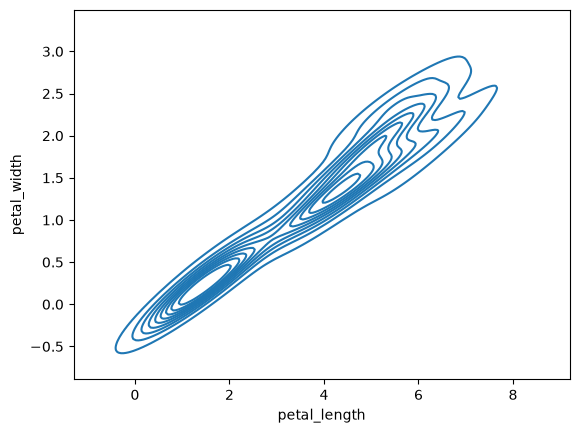

In [25]:
import seaborn as sns
df = sns.load_dataset('iris')
sns.kdeplot(x=df['petal_length'],y=df['petal_width'])


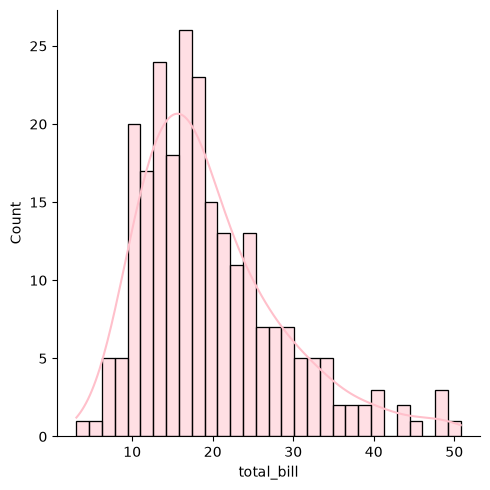

In [29]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.displot(data['total_bill'],kde = True,color = 'pink',bins =30)

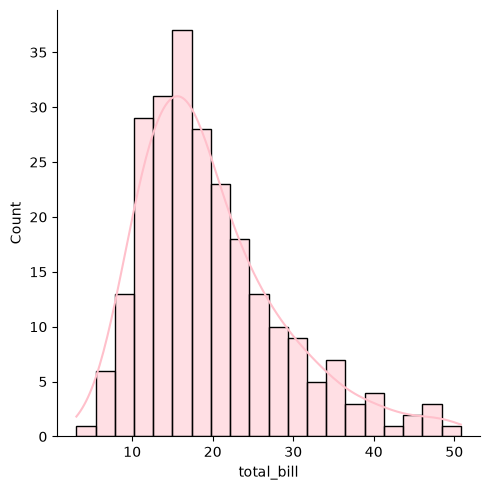

In [27]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.displot(data['total_bill'],kde = True,color = 'pink',bins =20)

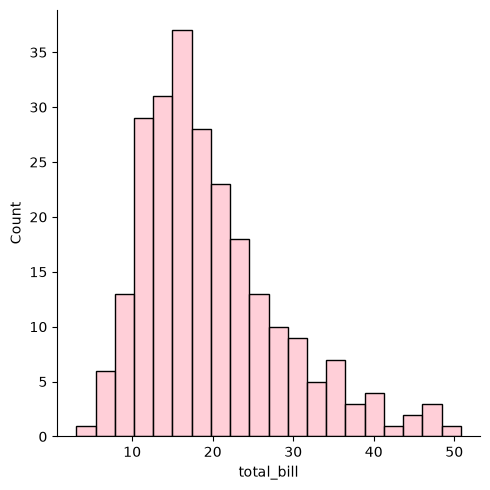

In [30]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.displot(data['total_bill'],kde = False,color = 'pink',bins =20)

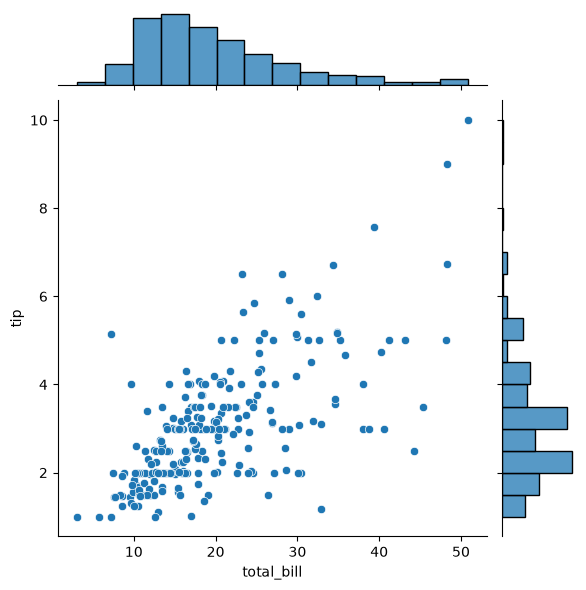

In [31]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.jointplot(x = 'total_bill',y='tip', data = data)

<Axes: xlabel='sex', ylabel='count'>

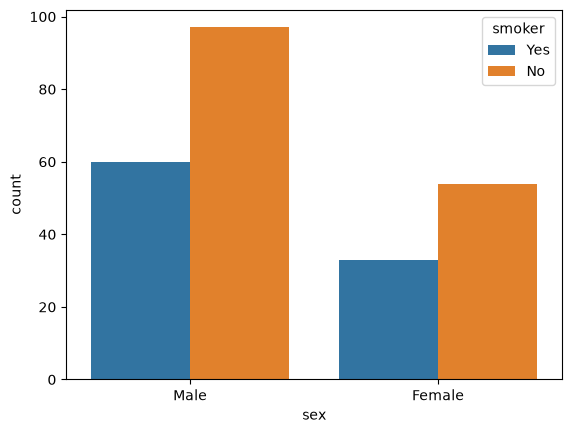

In [32]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.countplot(x='sex',hue='smoker',data=data)

<Axes: xlabel='count', ylabel='sex'>

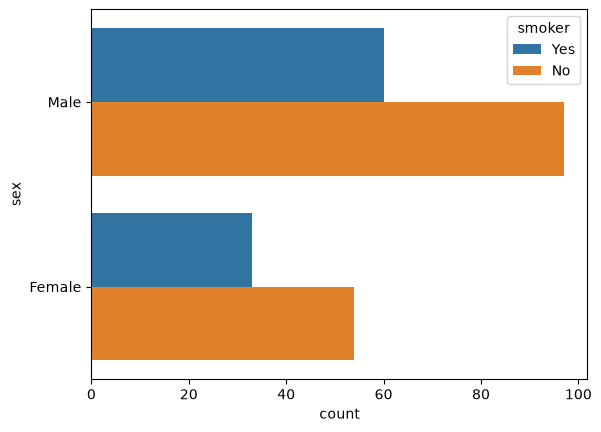

In [33]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.countplot(y='sex',hue='smoker',data=data)

<Axes: ylabel='total_bill'>

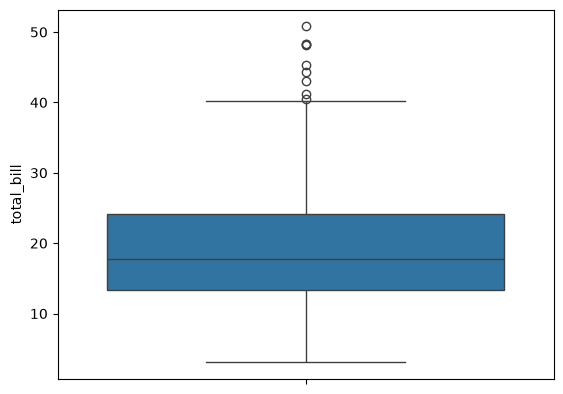

In [34]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.boxplot(data['total_bill'])

<Axes: ylabel='tip'>

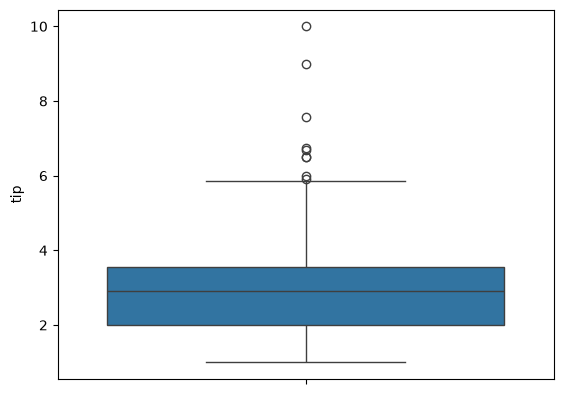

In [35]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.boxplot(data['tip'])

<Axes: ylabel='size'>

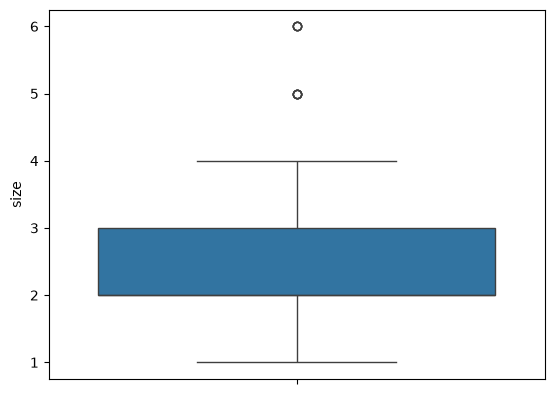

In [36]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.boxplot(data['size'])

{'whiskers': [<matplotlib.lines.Line2D at 0xd739140>,
 'caps': [<matplotlib.lines.Line2D at 0xd6e7d20>,
 'boxes': [<matplotlib.lines.Line2D at 0xd736390>],
 'medians': [<matplotlib.lines.Line2D at 0xd6fa580>],
 'fliers': [<matplotlib.lines.Line2D at 0xd6eb478>],
 'means': []}

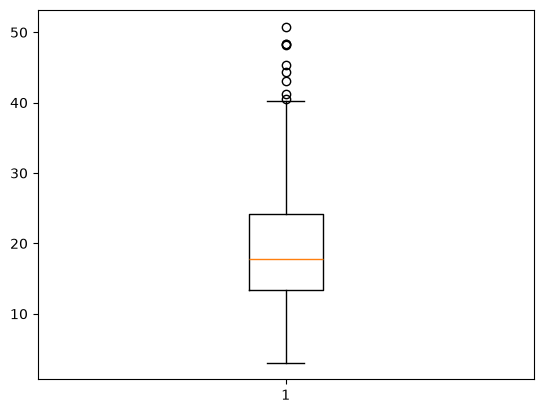

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('tips.csv')
import numpy as np
plt.boxplot(df['total_bill'])

In [2]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.741 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [3]:
!pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


{'whiskers': [<matplotlib.lines.Line2D at 0xda07fc8>,
 'caps': [<matplotlib.lines.Line2D at 0xd9f8d08>,
 'boxes': [<matplotlib.lines.Line2D at 0xda20920>],
 'medians': [<matplotlib.lines.Line2D at 0xd9e4668>],
 'fliers': [<matplotlib.lines.Line2D at 0xd9e43b0>],
 'means': []}

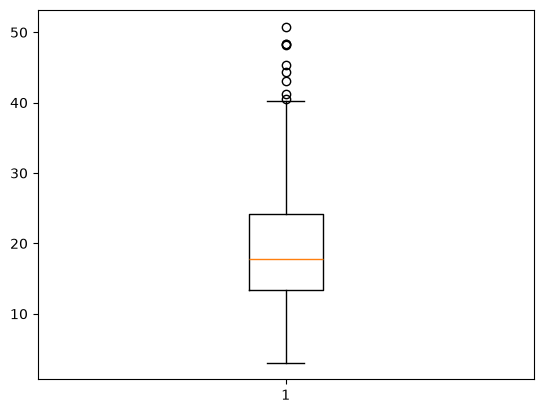

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('tips.csv')
import numpy as np
plt.boxplot(df['total_bill'])

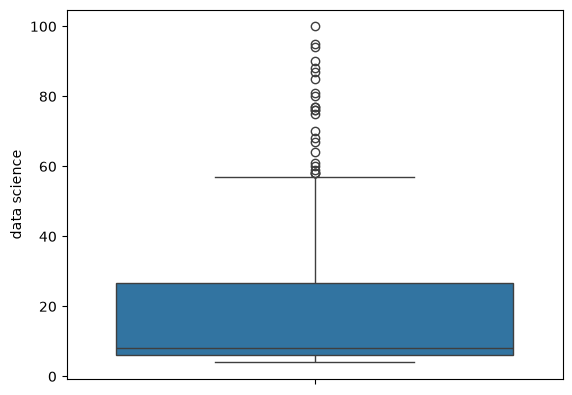

In [13]:
import seaborn as sns
import pandas as pd
df=pd.read_csv('temporal.csv')
df
sns.boxplot(df['data science'])
plt.show()

In [15]:
import seaborn as sns
import pandas as pd
import numpy as np
df=pd.read_csv('temporal.csv')
Q1=np.percentile(df['data science'],25,method='midpoint')
Q3=np.percentile(df['data science'],75,method='midpoint')
IQR=Q3-Q1
print("the output of IQR")
print(IQR)

the output of IQR
20.5


<Axes: >

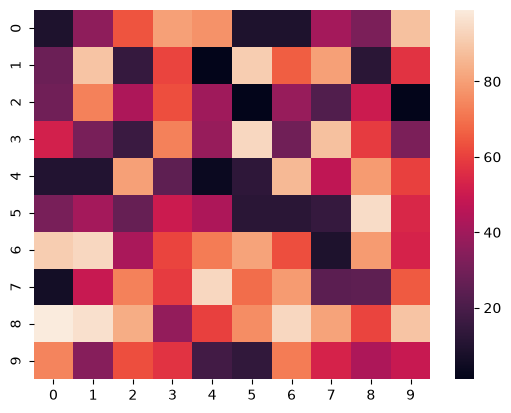

In [16]:
#heat for 1 to 100
import seaborn as sns
import numpy as np
data = np.random.randint(1,100,(10,10))
sns.heatmap(data)

<Axes: >

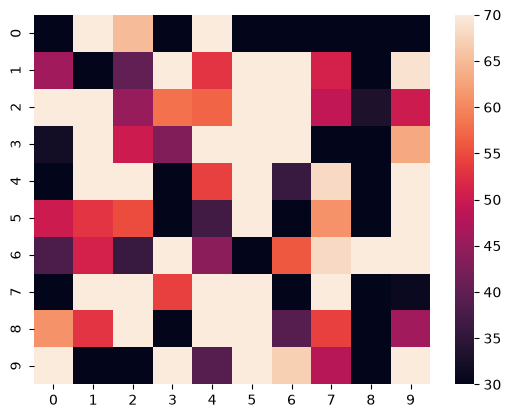

In [17]:
import seaborn as sns
import numpy as np
data = np.random.randint(1,100,(10,10))
sns.heatmap(data,vmin=30,vmax=70)

<Axes: >

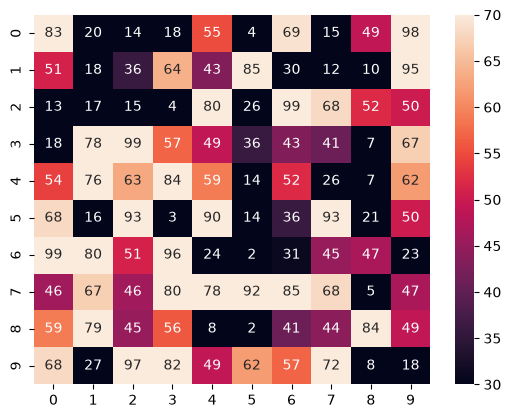

In [18]:
import seaborn as sns
import numpy as np
data = np.random.randint(1,100,(10,10))
sns.heatmap(data,vmin=30,vmax=70,annot=True)

<Axes: >

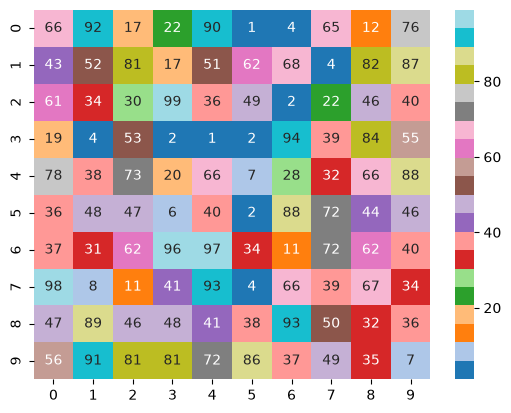

In [19]:
import seaborn as sns
import numpy as np
data = np.random.randint(1,100,(10,10))
sns.heatmap(data,cmap='tab20',annot=True)

<Axes: >

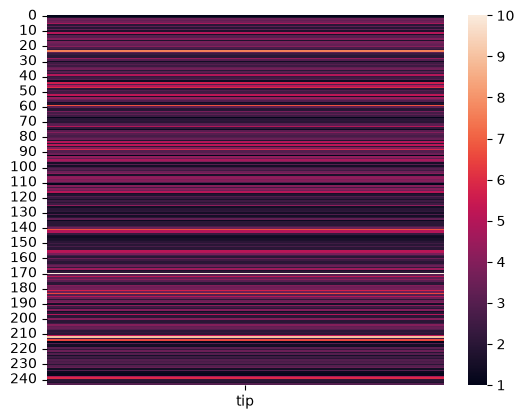

In [21]:
import seaborn as sns
data = sns.load_dataset("tips")
sns.heatmap(data[['tip']])

<Axes: >

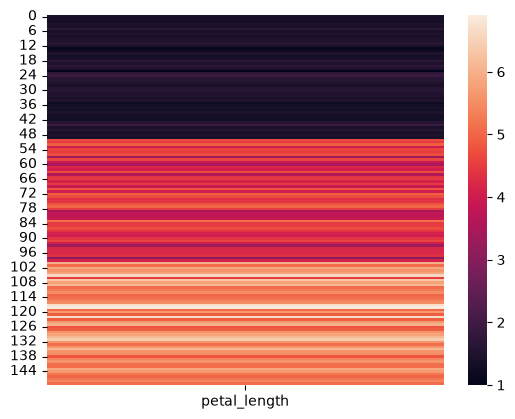

In [24]:
import seaborn as sns
data = sns.load_dataset("iris")
sns.heatmap(data[['petal_length']])

<Axes: >

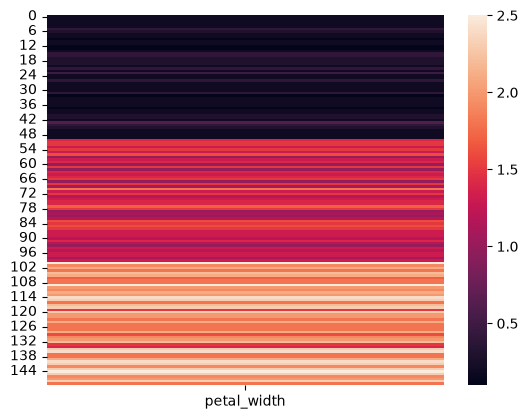

In [25]:
import seaborn as sns
data = sns.load_dataset("iris")
sns.heatmap(data[['petal_width']])

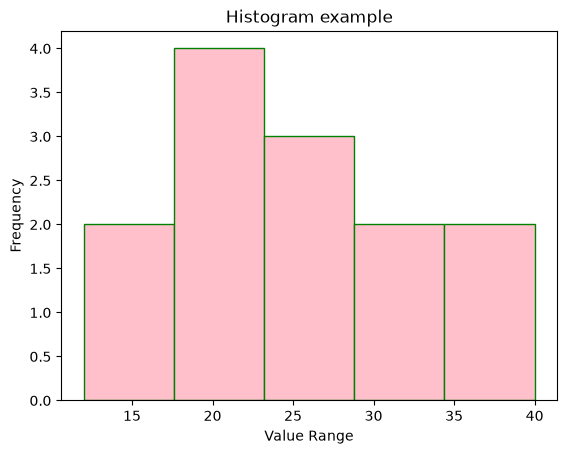

In [27]:
import matplotlib.pyplot as plt
data = [12,15,20,20,22,23,25,25,25,30,32,35,40]
plt.hist(data,bins=5,color='pink',edgecolor = 'green')
plt.title("Histogram example")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

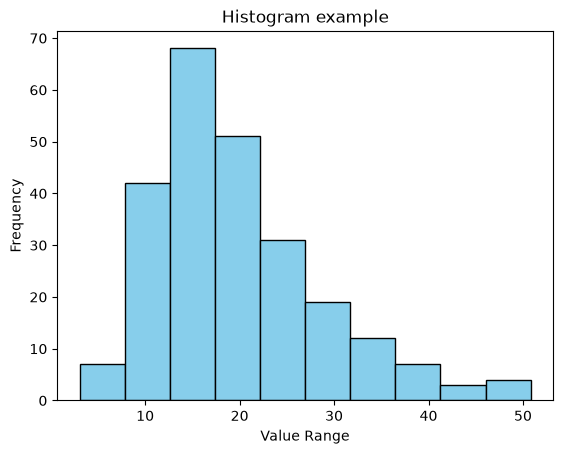

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
data = sns.load_dataset("tips")
plt.hist(data['total_bill'],bins=10,color='skyblue', edgecolor = 'black')
plt.title("Histogram example")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

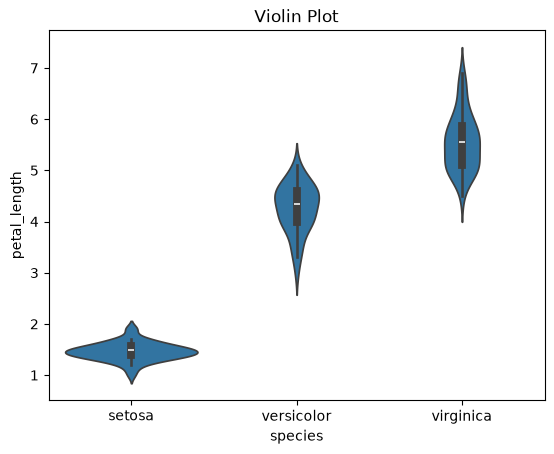

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
df=sns.load_dataset('iris')
sns.violinplot(x='species',y='petal_length',data =df)
plt.title('Violin Plot')
plt.show()